# Chapter 9 — Orthogonal Matrices and QR Decomposition

## Learning Objectives

This notebook covers orthogonal matrices, Gram-Schmidt intuition, QR decomposition, and QR-based reconstruction.

## Theoretical Explanation

An orthogonal matrix has columns that are mutually orthogonal and unit length. This gives the important property `Q.T @ Q = I`, meaning the inverse of an orthogonal matrix is its transpose. QR decomposition factors a matrix into an orthogonal matrix `Q` and an upper-triangular matrix `R`.

QR decomposition is important for numerical stability and least-squares solving. It also demonstrates how matrix decompositions reveal structure hidden inside a matrix.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Orthogonal Matrix Check

Q.T @ Q close to identity? True
Reconstruction error: 1.444157033281678e-15


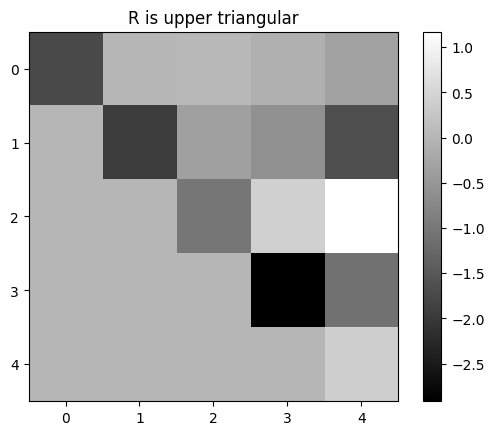

In [2]:
A = np.random.randn(5,5)
Q, R = np.linalg.qr(A)
print('Q.T @ Q close to identity?', np.allclose(Q.T @ Q, np.eye(5)))
print('Reconstruction error:', norm(A - Q @ R))
plt.imshow(R, cmap='gray')
plt.title('R is upper triangular')
plt.colorbar(); plt.show()

### Output Interpretation

`Q.T @ Q` confirms orthogonality. The small reconstruction error confirms that `A = Q @ R`. The plot shows the upper-triangular structure of `R`.

## 2. QR for a Tall Matrix

In [3]:
T = np.random.randn(8,3)
Q, R = np.linalg.qr(T, mode='reduced')
print('T shape:', T.shape)
print('Q shape:', Q.shape)
print('R shape:', R.shape)
print('Q.T @ Q:\n', np.round(Q.T @ Q, 6))
print('Reconstruction error:', norm(T-Q@R))

T shape: (8, 3)
Q shape: (8, 3)
R shape: (3, 3)
Q.T @ Q:
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
Reconstruction error: 7.696935026071522e-16


### Output Interpretation

Reduced QR keeps only the necessary orthogonal columns. This is useful when the input matrix is tall, as in many data science design matrices.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.